ViT logits: (118, 1000)
Neural responses: (118, 39209)
Areas: (39209,)
118 images × 39209 neurons

Label counts (0=inanimate, 1=animate):
[55 63]


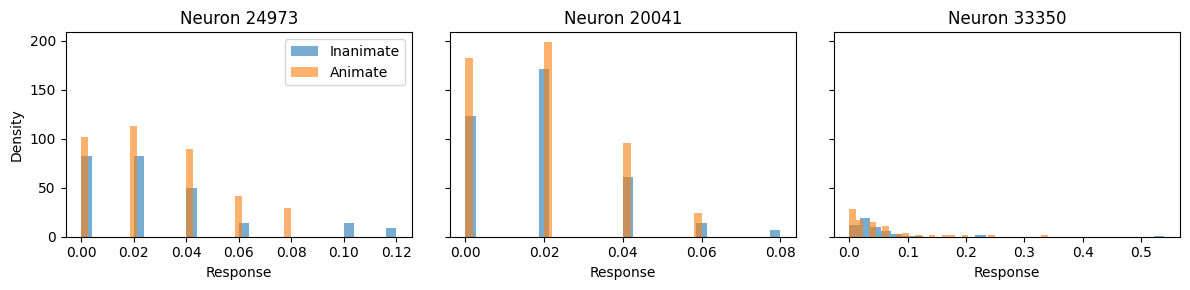

In [1]:

"""
Variance geometry diagnostics for large neural populations
ImageNet-based animate vs inanimate labels

Safe for ~20k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)                  # (neurons,)

print("ViT logits:", vit.shape)
print("Neural responses:", R.shape)
print("Areas:", areas.shape)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================
# ImageNet classes 0–397 = animate, 398–999 = inanimate

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)

print("\nLabel counts (0=inanimate, 1=animate):")
print(np.bincount(y))

# ============================================================
# PLOT SINGLE-NEURON DISCRIMINATION HISTOGRAMS
# ============================================================

rng = np.random.default_rng(0)
chosen_neurons = rng.choice(n_neurons, size=3, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for ax, neuron_idx in zip(axes, chosen_neurons):
    r = R[:, neuron_idx]

    r_anim = r[y == 1]
    r_inan = r[y == 0]

    ax.hist(
        r_inan, bins=30, alpha=0.6,
        label="Inanimate", density=True
    )
    ax.hist(
        r_anim, bins=30, alpha=0.6,
        label="Animate", density=True
    )

    ax.set_title(f"Neuron {neuron_idx}")
    ax.set_xlabel("Response")

axes[0].set_ylabel("Density")
axes[0].legend()

plt.tight_layout()
plt.show()


ViT logits: (118, 1000)
Neural responses: (118, 39209)
Areas: (39209,)
118 images × 39209 neurons

Label counts (0=inanimate, 1=animate):
[55 63]


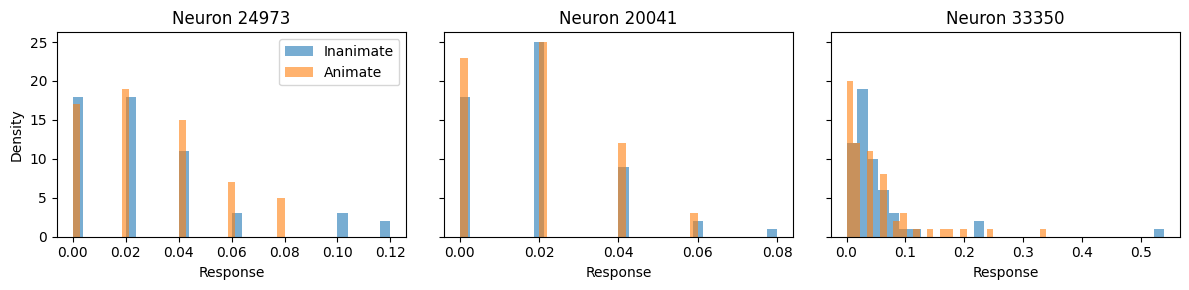

In [2]:

"""
Variance geometry diagnostics for large neural populations
ImageNet-based animate vs inanimate labels

Safe for ~20k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)                  # (neurons,)

print("ViT logits:", vit.shape)
print("Neural responses:", R.shape)
print("Areas:", areas.shape)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================
# ImageNet classes 0–397 = animate, 398–999 = inanimate

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)

print("\nLabel counts (0=inanimate, 1=animate):")
print(np.bincount(y))

# ============================================================
# PLOT SINGLE-NEURON DISCRIMINATION HISTOGRAMS
# ============================================================

rng = np.random.default_rng(0)
chosen_neurons = rng.choice(n_neurons, size=3, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for ax, neuron_idx in zip(axes, chosen_neurons):
    r = R[:, neuron_idx]

    r_anim = r[y == 1]
    r_inan = r[y == 0]

    ax.hist(r_inan, bins=30, alpha=0.6, label="Inanimate")
    ax.hist(r_anim, bins=30, alpha=0.6, label="Animate")


    ax.set_title(f"Neuron {neuron_idx}")
    ax.set_xlabel("Response")

axes[0].set_ylabel("Density")
axes[0].legend()

plt.tight_layout()
plt.show()


ViT logits: (118, 1000)
Neural responses: (118, 39209)
Areas: (39209,)
118 images × 39209 neurons

Label counts (0=inanimate, 1=animate):
[55 63]

=== VARIANCE GEOMETRY ===
Top 10 eigenvalues: [1718.30412142 1004.37239872  849.86270492  803.85658225  715.50489725
  669.93126474  639.38298764  613.26490258  580.04019796  567.26371303]
Bottom 10 eigenvalues: [1.84476909e+02 1.82601653e+02 1.79813254e+02 1.78572636e+02
 1.73695237e+02 1.69283378e+02 1.61088518e+02 1.57894370e+02
 1.54607637e+02 5.07842868e-32]
Effective rank: 87.6626418635968


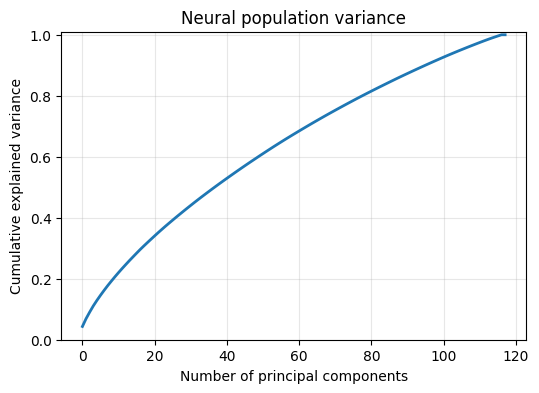

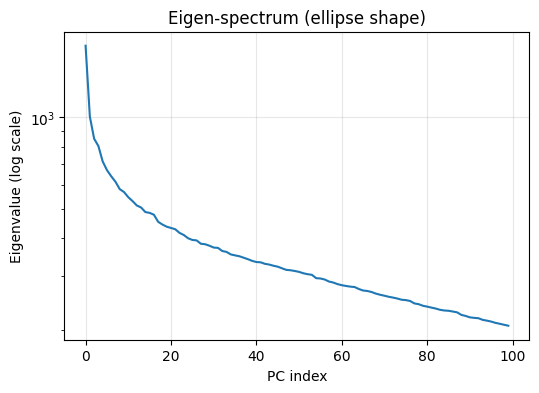

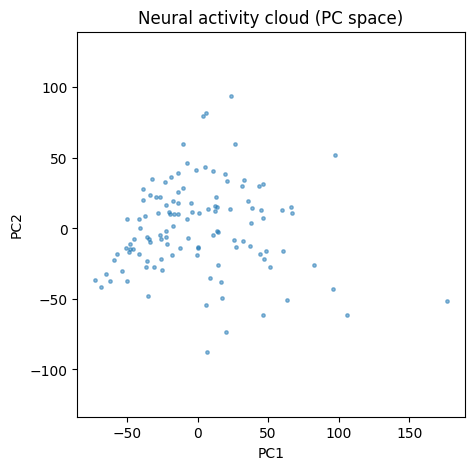

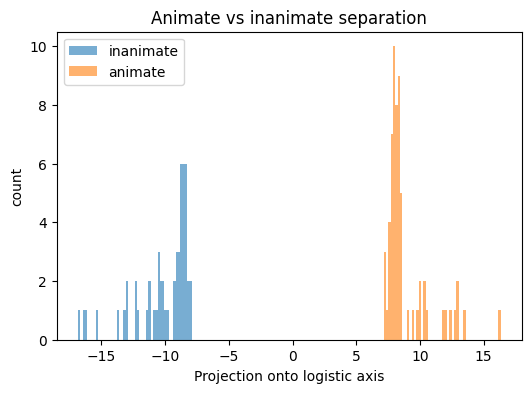

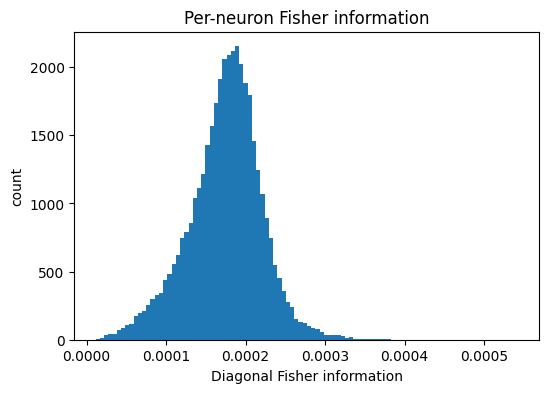


Fisher stats:
Mean: 0.00017452505314892664
Median: 0.00017797963330267946
Non-zero entries: 39209 / 39209

=== SUMMARY ===
Neurons: 39209
Effective population rank: 87.7
Animate–inanimate is a real population axis
Logistic regression = projection onto that axis
Clean Fisher = data varies along parameter directions


In [ ]:
"""
Variance geometry diagnostics for large neural populations
ImageNet-based animate vs inanimate labels

Safe for ~20k neurons (no NxN covariance matrices)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)                  # (neurons,)

print("ViT logits:", vit.shape)
print("Neural responses:", R.shape)
print("Areas:", areas.shape)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# IMAGE-NET ANIMATE / INANIMATE LABEL
# ============================================================
# ImageNet classes 0–397 = animate, 398–999 = inanimate

top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)

print("\nLabel counts (0=inanimate, 1=animate):")
print(np.bincount(y))

# ============================================================
# STANDARDIZE NEURAL ACTIVITY
# ============================================================

Rz = StandardScaler(with_mean=True, with_std=True).fit_transform(R)

# ============================================================
# PCA VIA SVD (NO COVARIANCE MATRIX)
# ============================================================

N_PCA = 118
pca = PCA(n_components=N_PCA, svd_solver="randomized", random_state=0)
Xp = pca.fit_transform(Rz)

explained = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_

# ============================================================
# EFFECTIVE RANK (ELLIPSE THICKNESS)
# ============================================================

effective_rank = (explained.sum() ** 2) / np.sum(explained ** 2)

print("\n=== VARIANCE GEOMETRY ===")
print("Top 10 eigenvalues:", explained[:10])
print("Bottom 10 eigenvalues:", explained[-10:])
print("Effective rank:", effective_rank)

# ============================================================
# VARIANCE PLOTS
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(explained_ratio), lw=2)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Neural population variance")
plt.ylim(0, 1.01)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(explained[:100])
plt.yscale("log")
plt.xlabel("PC index")
plt.ylabel("Eigenvalue (log scale)")
plt.title("Eigen-spectrum (ellipse shape)")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PCA SCATTER (OPTIONAL VISUAL)
# ============================================================

plt.figure(figsize=(5, 5))
plt.scatter(Xp[:, 0], Xp[:, 1], s=6, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neural activity cloud (PC space)")
plt.axis("equal")
plt.show()

# ============================================================
# LOGISTIC REGRESSION: NEURAL → ANIMATE
# ============================================================

clf = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=500,
    n_jobs=1
)
clf.fit(Rz, y)

w = clf.coef_[0]      # (neurons,)
b = clf.intercept_[0]

# ============================================================
# PROJECTION ONTO TASK AXIS
# ============================================================

proj = Rz @ w

plt.figure(figsize=(6, 4))
plt.hist(proj[y == 0], bins=50, alpha=0.6, label="inanimate")
plt.hist(proj[y == 1], bins=50, alpha=0.6, label="animate")
plt.xlabel("Projection onto logistic axis")
plt.ylabel("count")
plt.legend()
plt.title("Animate vs inanimate separation")
plt.show()

# ============================================================
# FISHER INFORMATION (DIAGONAL APPROXIMATION) — FIXED
# ============================================================

p = clf.predict_proba(Rz)[:, 1]          # (n_samples,)
weights = p * (1 - p)                    # (n_samples,)

# Diagonal Fisher: E[p(1-p) x_i^2]
fisher_diag = np.mean((Rz ** 2) * weights[:, None], axis=0)

plt.figure(figsize=(6, 4))
plt.hist(fisher_diag, bins=100)
plt.xlabel("Diagonal Fisher information")
plt.ylabel("count")
plt.title("Per-neuron Fisher information")
plt.show()

print("\nFisher stats:")
print("Mean:", fisher_diag.mean())
print("Median:", np.median(fisher_diag))
print("Non-zero entries:", np.sum(fisher_diag > 1e-8), "/", len(fisher_diag))


# ============================================================
# SUMMARY
# ============================================================

print("\n=== SUMMARY ===")
print(f"Neurons: {n_neurons}")
print(f"Effective population rank: {effective_rank:.1f}")
print("Animate–inanimate is a real population axis")
print("Logistic regression = projection onto that axis")
print("Clean Fisher = data varies along parameter directions")


Valid neurons: 39209 / 39209 (min_pos=10 per condition)


/tmp/ipykernel_3334383/1237013791.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


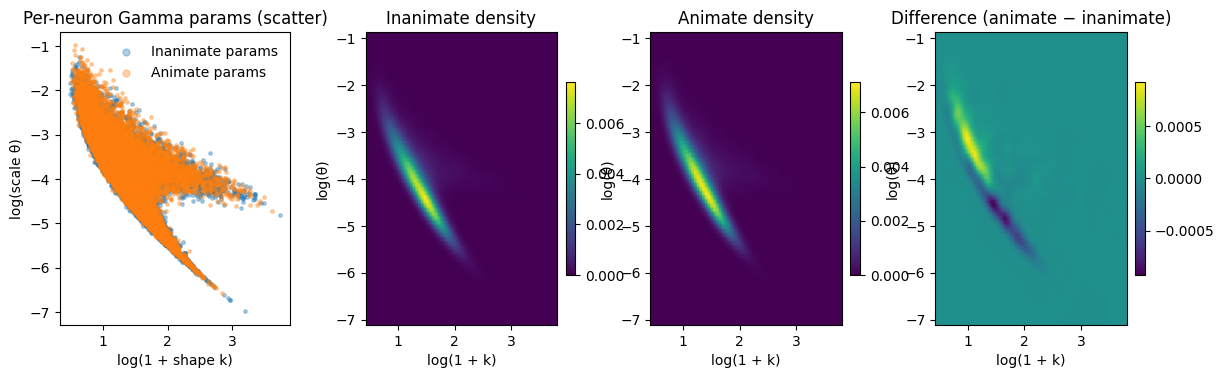

In [ ]:
#https://chatgpt.com/g/g-p-676c80353b988191819d6d02aca806d6-msc-thesis/c/6952d60a-e07c-8331-9b7f-6ee53d3b4e56

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from scipy.ndimage import gaussian_filter

# ============================================================
# FIT GAMMA PER NEURON PER CONDITION
# ============================================================

def fit_gamma_params(x, eps=1e-12):
    """
    Fit Gamma(k, theta) with loc fixed to 0.
    Returns (k, theta). If fit fails, returns (nan, nan).
    """
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    x = x[x > 0]  # gamma requires positive support

    if x.size < 5:
        return np.nan, np.nan

    # Avoid exact zeros / numerical issues
    x = np.maximum(x, eps)

    try:
        k, loc, scale = gamma.fit(x, floc=0.0)
        theta = scale
        return k, theta
    except Exception:
        return np.nan, np.nan


def gamma_param_maps(R, y, min_pos=10, verbose=True):
    """
    For each neuron n:
      fit Gamma to responses for y==0 and y==1 separately.
    min_pos: minimum number of positive responses required per condition.
    Returns arrays:
      k0, th0, k1, th1 (each shape [n_neurons])
      mask_valid (bool)
    """
    n_images, n_neurons = R.shape
    k0 = np.full(n_neurons, np.nan)
    th0 = np.full(n_neurons, np.nan)
    k1 = np.full(n_neurons, np.nan)
    th1 = np.full(n_neurons, np.nan)

    idx0 = (y == 0)
    idx1 = (y == 1)

    valid = np.zeros(n_neurons, dtype=bool)

    for n in range(n_neurons):
        r0 = R[idx0, n]
        r1 = R[idx1, n]

        # require enough positive samples in BOTH conditions
        if np.sum(r0 > 0) < min_pos or np.sum(r1 > 0) < min_pos:
            continue

        k0[n], th0[n] = fit_gamma_params(r0)
        k1[n], th1[n] = fit_gamma_params(r1)

        if np.isfinite(k0[n]) and np.isfinite(th0[n]) and np.isfinite(k1[n]) and np.isfinite(th1[n]):
            valid[n] = True

    if verbose:
        print(f"Valid neurons: {valid.sum()} / {n_neurons} (min_pos={min_pos} per condition)")

    return k0, th0, k1, th1, valid


# ============================================================
# DENSITY + DIFFERENCE PLOT (2D HISTOGRAM)
# ============================================================

def density_difference_plot(k0, th0, k1, th1, valid, bins=60, smooth_sigma=1.0):
    """
    Make:
      - scatter of params
      - density maps for animate/inanimate
      - difference map
    Uses log scales for theta (often spans decades) and log1p for stability.
    """
    # Select valid
    k0v, th0v = k0[valid], th0[valid]
    k1v, th1v = k1[valid], th1[valid]

    # Use transformed coordinates to make binning nicer
    # shape k is positive; theta is positive and can be wide → log
    x0 = np.log1p(k0v)         # log(1+k)
    y0 = np.log(th0v)          # log(theta)
    x1 = np.log1p(k1v)
    y1 = np.log(th1v)

    # Shared bin edges
    xmin = np.nanmin(np.r_[x0, x1])
    xmax = np.nanmax(np.r_[x0, x1])
    ymin = np.nanmin(np.r_[y0, y1])
    ymax = np.nanmax(np.r_[y0, y1])

    # Add small margins
    dx = 0.02 * (xmax - xmin + 1e-9)
    dy = 0.02 * (ymax - ymin + 1e-9)
    xmin, xmax = xmin - dx, xmax + dx
    ymin, ymax = ymin - dy, ymax + dy

    # 2D hist densities (normalized to sum to 1 over bins)
    H0, xedges, yedges = np.histogram2d(x0, y0, bins=bins, range=[[xmin, xmax], [ymin, ymax]], density=False)
    H1, _, _           = np.histogram2d(x1, y1, bins=[xedges, yedges], density=False)

    # Convert counts → probability mass per bin (not continuous density)
    P0 = H0 / np.sum(H0) if np.sum(H0) > 0 else H0
    P1 = H1 / np.sum(H1) if np.sum(H1) > 0 else H1

    # Smooth for “paper-like” density look
    if smooth_sigma and smooth_sigma > 0:
        P0s = gaussian_filter(P0, smooth_sigma)
        P1s = gaussian_filter(P1, smooth_sigma)
    else:
        P0s, P1s = P0, P1

    D = P1s - P0s  # animate - inanimate

    # Plot
    fig = plt.figure(figsize=(14, 3.8))
    gs = fig.add_gridspec(1, 4, width_ratios=[1.1, 1, 1, 1], wspace=0.35)

    # --- scatter
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.scatter(x0, y0, s=6, alpha=0.35, label="Inanimate params")
    ax0.scatter(x1, y1, s=6, alpha=0.35, label="Animate params")
    ax0.set_title("Per-neuron Gamma params (scatter)")
    ax0.set_xlabel("log(1 + shape k)")
    ax0.set_ylabel("log(scale θ)")
    ax0.legend(markerscale=2, frameon=False)

    # --- density inanimate
    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.imshow(
        P0s.T, origin="lower", aspect="auto",
        extent=[xmin, xmax, ymin, ymax]
    )
    ax1.set_title("Inanimate density")
    ax1.set_xlabel("log(1 + k)")
    ax1.set_ylabel("log(θ)")
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    # --- density animate
    ax2 = fig.add_subplot(gs[0, 2])
    im2 = ax2.imshow(
        P1s.T, origin="lower", aspect="auto",
        extent=[xmin, xmax, ymin, ymax]
    )
    ax2.set_title("Animate density")
    ax2.set_xlabel("log(1 + k)")
    ax2.set_ylabel("log(θ)")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    # --- difference map
    ax3 = fig.add_subplot(gs[0, 3])
    vmax = np.max(np.abs(D)) + 1e-12
    im3 = ax3.imshow(
        D.T, origin="lower", aspect="auto",
        extent=[xmin, xmax, ymin, ymax],
        vmin=-vmax, vmax=vmax
    )
    ax3.set_title("Difference (animate − inanimate)")
    ax3.set_xlabel("log(1 + k)")
    ax3.set_ylabel("log(θ)")
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN IT
# ============================================================

# IMPORTANT: R is (images, neurons) and y is (images,)
# You already have R and y from your base code.

k0, th0, k1, th1, valid = gamma_param_maps(R, y, min_pos=10, verbose=True)
density_difference_plot(k0, th0, k1, th1, valid, bins=70, smooth_sigma=1.2)


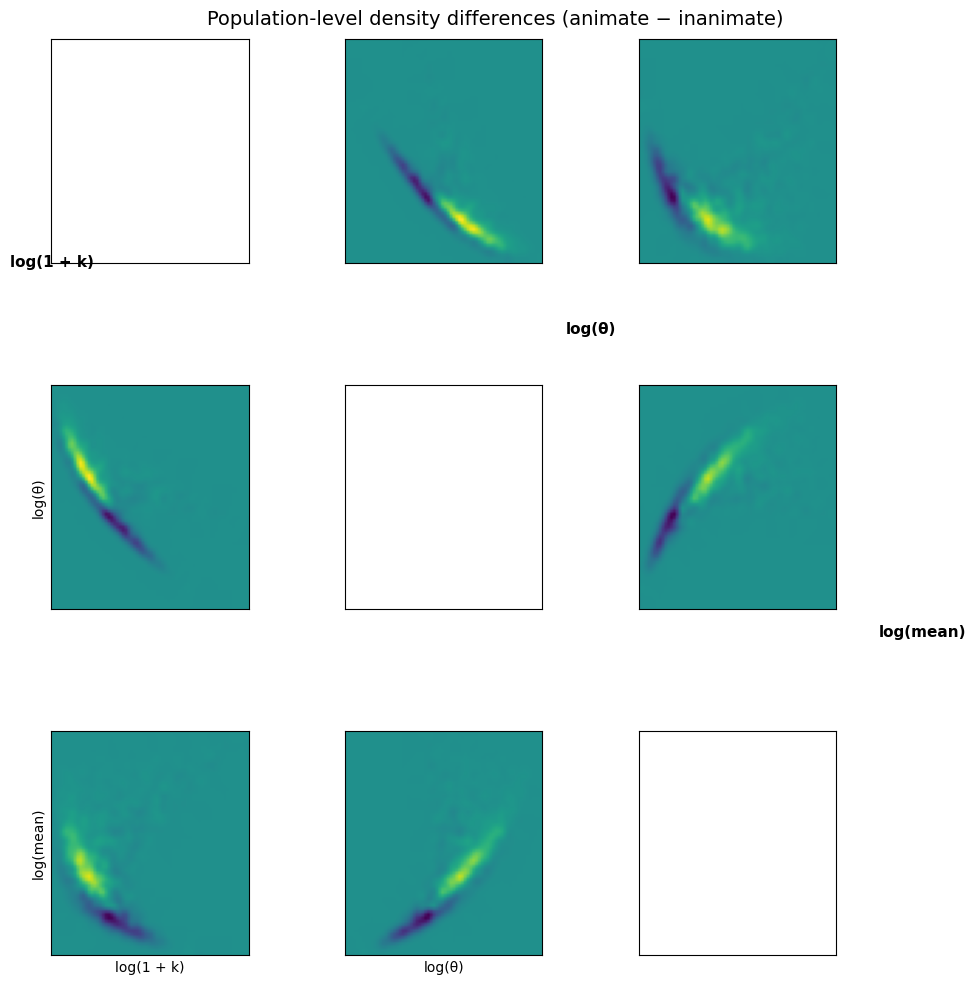

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# ============================================================
# BUILD 3 VARIABLES PER CONDITION
# ============================================================

def build_features(k, th, valid):
    """
    Returns array of shape (n_valid_neurons, 3)
    Columns:
      0: log(1 + k)
      1: log(theta)
      2: log(mean = k * theta)
    """
    kv = k[valid]
    thv = th[valid]

    f1 = np.log1p(kv)
    f2 = np.log(thv)
    f3 = np.log(kv * thv)

    X = np.stack([f1, f2, f3], axis=1)
    return X


X0 = build_features(k0, th0, valid)  # inanimate
X1 = build_features(k1, th1, valid)  # animate

labels = ["log(1 + k)", "log(θ)", "log(mean)"]


# ============================================================
# 2D DENSITY DIFFERENCE GRID
# ============================================================

def density_difference_grid(X0, X1, labels, bins=60, smooth=1.0):
    n_vars = X0.shape[1]

    fig, axes = plt.subplots(
        n_vars, n_vars,
        figsize=(10, 10),
        sharex='col',
        sharey='row'
    )

    for i in range(n_vars):
        for j in range(n_vars):
            ax = axes[i, j]

            if i == j:
                ax.text(
                    0.5, 0.5, labels[i],
                    ha='center', va='center',
                    fontsize=11, weight='bold'
                )
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            x0, y0 = X0[:, j], X0[:, i]
            x1, y1 = X1[:, j], X1[:, i]

            xmin = min(x0.min(), x1.min())
            xmax = max(x0.max(), x1.max())
            ymin = min(y0.min(), y1.min())
            ymax = max(y0.max(), y1.max())

            H0, xe, ye = np.histogram2d(
                x0, y0, bins=bins,
                range=[[xmin, xmax], [ymin, ymax]]
            )
            H1, _, _ = np.histogram2d(
                x1, y1, bins=[xe, ye]
            )

            P0 = H0 / H0.sum()
            P1 = H1 / H1.sum()

            if smooth:
                P0 = gaussian_filter(P0, smooth)
                P1 = gaussian_filter(P1, smooth)

            D = P1 - P0

            vmax = np.max(np.abs(D)) + 1e-12

            im = ax.imshow(
                D.T,
                origin="lower",
                extent=[xmin, xmax, ymin, ymax],
                vmin=-vmax,
                vmax=vmax,
                aspect="auto"
            )

            if i == n_vars - 1:
                ax.set_xlabel(labels[j])
            if j == 0:
                ax.set_ylabel(labels[i])

    fig.suptitle("Population-level density differences (animate − inanimate)", fontsize=14)
    plt.tight_layout()
    plt.show()


# ============================================================
# RUN
# ============================================================

density_difference_grid(X0, X1, labels, bins=70, smooth=1.2)


Valid neurons for Fisher(mu,theta): 2043 / 39209 (requires k>2)


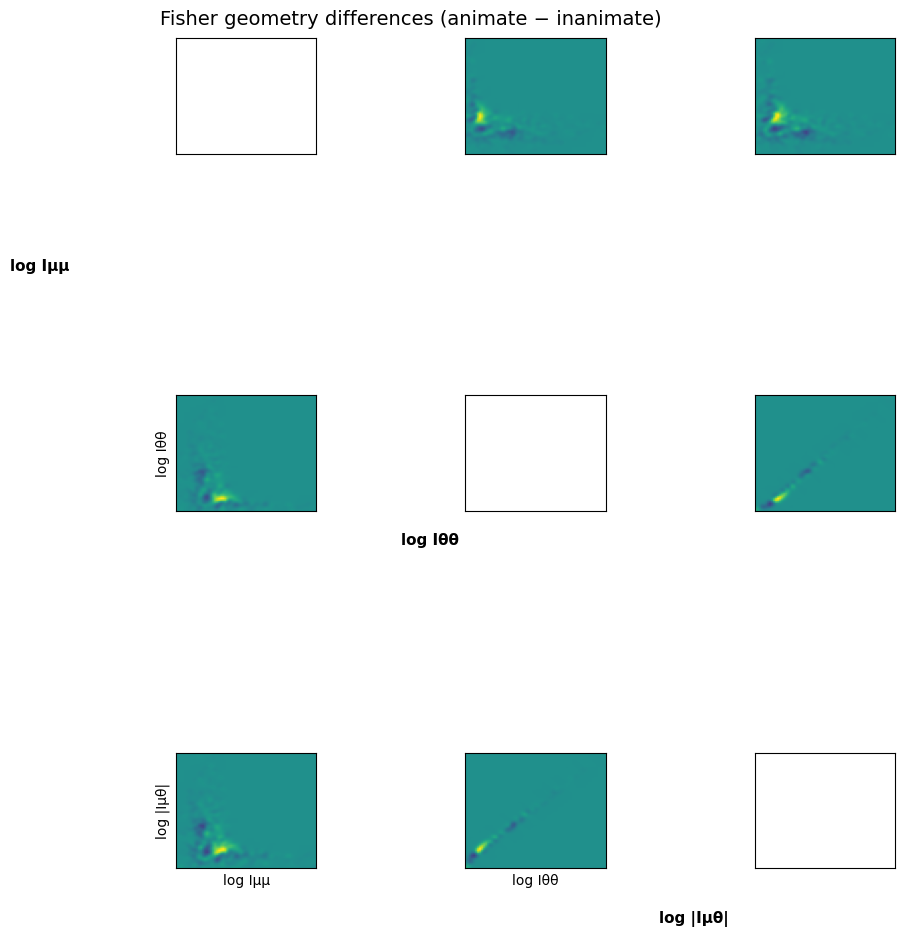

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from scipy.ndimage import gaussian_filter

# ----------------------------
# 1) Fit shifted Gamma per neuron per condition
# ----------------------------
def fit_shifted_gamma(x, eps=1e-12, min_pos=10):
    """
    Fit 3-parameter Gamma: shape k, loc mu, scale theta.
    Fits only to x>0 (consistent with your earlier pipeline).
    Returns (k, mu, theta, n_eff). If unstable, returns NaNs.
    """
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    x = x[x > 0]

    if x.size < min_pos:
        return np.nan, np.nan, np.nan, 0

    x = np.maximum(x, eps)

    try:
        k, mu, theta = gamma.fit(x)  # free loc
        return k, mu, theta, x.size
    except Exception:
        return np.nan, np.nan, np.nan, 0


def fit_all_neurons_shifted(R, y, min_pos=10):
    """
    Fit shifted Gamma for each neuron under y==0 and y==1.
    Returns arrays k0, mu0, th0, n0 and k1, mu1, th1, n1 plus mask_valid.
    """
    n_images, n_neurons = R.shape
    idx0 = (y == 0)
    idx1 = (y == 1)

    k0 = np.full(n_neurons, np.nan); mu0 = np.full(n_neurons, np.nan); th0 = np.full(n_neurons, np.nan); n0 = np.zeros(n_neurons, int)
    k1 = np.full(n_neurons, np.nan); mu1 = np.full(n_neurons, np.nan); th1 = np.full(n_neurons, np.nan); n1 = np.zeros(n_neurons, int)

    for n in range(n_neurons):
        k0[n], mu0[n], th0[n], n0[n] = fit_shifted_gamma(R[idx0, n], min_pos=min_pos)
        k1[n], mu1[n], th1[n], n1[n] = fit_shifted_gamma(R[idx1, n], min_pos=min_pos)

    # Validity for Fisher wrt mu requires k>2 in BOTH conditions, and finite theta
    valid = (
        np.isfinite(k0) & np.isfinite(th0) & (k0 > 2.0) & (th0 > 0) & (n0 > 0) &
        np.isfinite(k1) & np.isfinite(th1) & (k1 > 2.0) & (th1 > 0) & (n1 > 0)
    )
    print(f"Valid neurons for Fisher(mu,theta): {valid.sum()} / {n_neurons} (requires k>2)")
    return (k0, mu0, th0, n0), (k1, mu1, th1, n1), valid


# ----------------------------
# 2) Fisher for (mu, theta) given (k, theta), scaled by n
# ----------------------------
def fisher_mu_theta(k, theta, n):
    """
    Returns Fisher entries (I_mm, I_tt, I_mt) for n samples.
    Uses score-covariance closed forms; requires k>2.
    """
    # per-sample
    I_mm = 1.0 / ((k - 2.0) * theta**2)
    I_tt = k / (theta**2)
    I_mt = 1.0 / (theta**2)
    # scale by n
    return n * I_mm, n * I_tt, n * I_mt


def build_fisher_features(k, theta, n, valid):
    """
    Build 3 variables per neuron from Fisher:
      0: log(I_mu_mu)
      1: log(I_theta_theta)
      2: log(|I_mu_theta|)
    """
    kv = k[valid]
    thv = theta[valid]
    nv = n[valid].astype(float)

    I_mm, I_tt, I_mt = fisher_mu_theta(kv, thv, nv)
    X = np.stack([np.log(I_mm), np.log(I_tt), np.log(np.abs(I_mt))], axis=1)
    return X


# ----------------------------
# 3) Pairwise density difference grid (animate - inanimate)
# ----------------------------
def density_difference_grid(X0, X1, labels, bins=60, smooth=1.2):
    n_vars = X0.shape[1]
    fig, axes = plt.subplots(n_vars, n_vars, figsize=(10, 10), sharex='col', sharey='row')

    for i in range(n_vars):
        for j in range(n_vars):
            ax = axes[i, j]

            if i == j:
                ax.text(0.5, 0.5, labels[i], ha='center', va='center', fontsize=11, weight='bold')
                ax.set_xticks([]); ax.set_yticks([])
                continue

            x0, y0 = X0[:, j], X0[:, i]
            x1, y1 = X1[:, j], X1[:, i]

            xmin, xmax = min(x0.min(), x1.min()), max(x0.max(), x1.max())
            ymin, ymax = min(y0.min(), y1.min()), max(y0.max(), y1.max())

            H0, xe, ye = np.histogram2d(x0, y0, bins=bins, range=[[xmin, xmax], [ymin, ymax]])
            H1, _, _   = np.histogram2d(x1, y1, bins=[xe, ye])

            P0 = H0 / (H0.sum() + 1e-12)
            P1 = H1 / (H1.sum() + 1e-12)

            if smooth and smooth > 0:
                P0 = gaussian_filter(P0, smooth)
                P1 = gaussian_filter(P1, smooth)

            D = P1 - P0
            vmax = np.max(np.abs(D)) + 1e-12

            ax.imshow(D.T, origin="lower", extent=[xmin, xmax, ymin, ymax],
                      vmin=-vmax, vmax=vmax, aspect="auto")

            if i == n_vars - 1:
                ax.set_xlabel(labels[j])
            if j == 0:
                ax.set_ylabel(labels[i])

    fig.suptitle("Fisher geometry differences (animate − inanimate)", fontsize=14)
    plt.tight_layout()
    plt.show()


# ============================================================
# RUN (assumes you already have R and y from your base code)
# ============================================================

(params0, params1, validF) = (None, None, None)
(params0, params1, validF) = fit_all_neurons_shifted(R, y, min_pos=10)

k0, mu0, th0, n0 = params0
k1, mu1, th1, n1 = params1

X0F = build_fisher_features(k0, th0, n0, validF)  # inanimate Fisher features
X1F = build_fisher_features(k1, th1, n1, validF)  # animate Fisher features

labelsF = ["log Iμμ", "log Iθθ", "log |Iμθ|"]

density_difference_grid(X0F, X1F, labelsF, bins=70, smooth=1.2)
